# House Price Prediction System
## Exploratory Data Analysis
### Objectives
- Understand the dataset
- Analyze the features
- Identify missing values
- Explore relationships between variables
- Prepare the data for preprocessing

## 1. Import Required Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import subprocess
import importlib
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [27]:
df = pd.read_csv("../data/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Dataset Overview

In [28]:
df.shape

(545, 13)

In [29]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [32]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [33]:
df.duplicated().sum()

0

In [34]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 4. Target Variable Analysis

The target variable for this project is **price**. Let's understand its distribution.

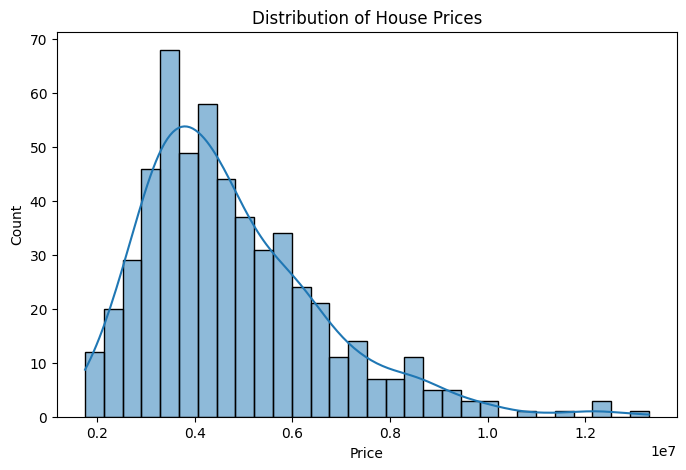

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

### Observation

- The house prices are slightly right-skewed.
- Most houses are concentrated in the lower to middle price range.

In [36]:
## 5. Numerical Feature Analysis

In [37]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

numerical_columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

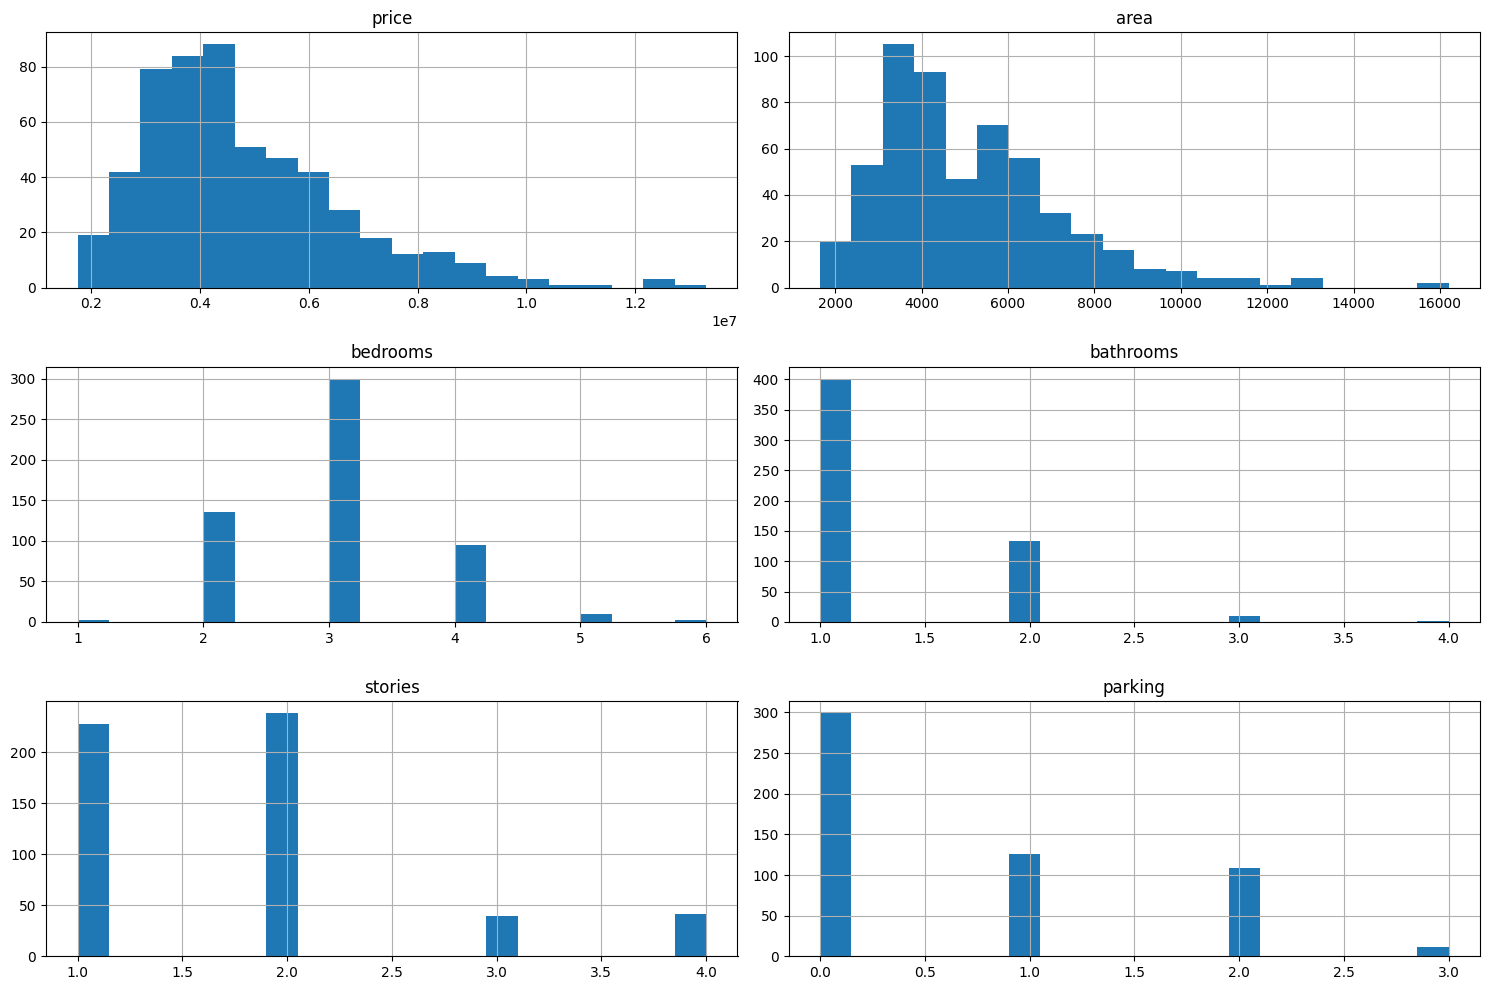

In [38]:
df[numerical_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

## 6. Categorical Feature Analysis

In [39]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

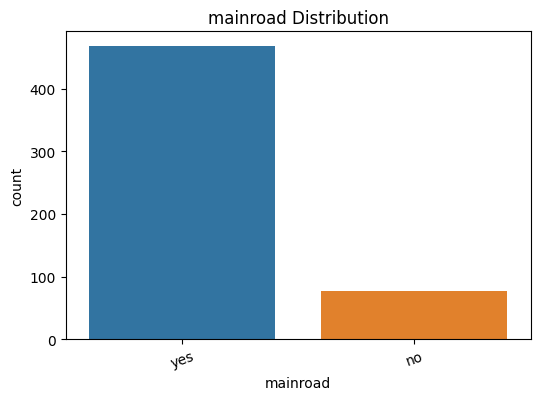

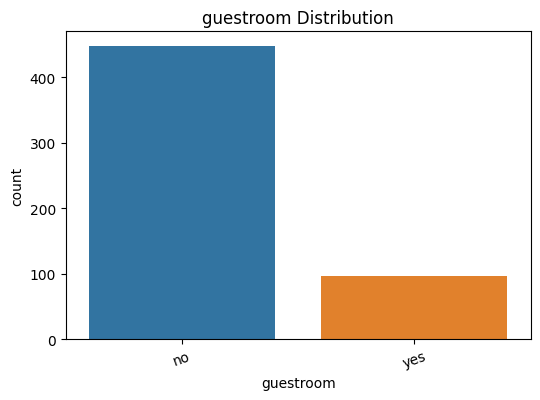

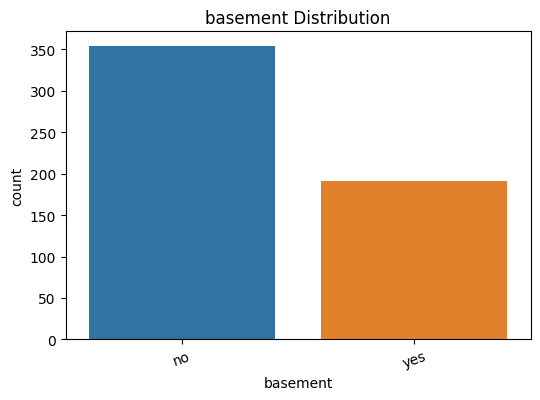

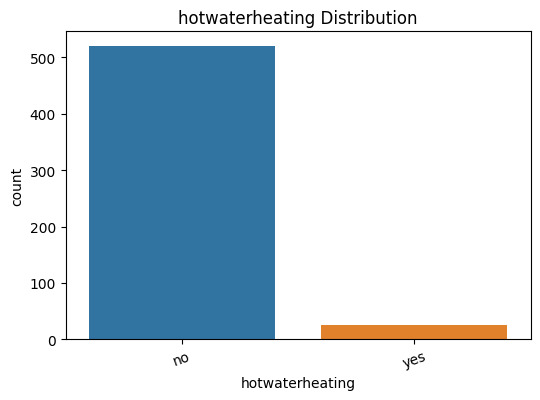

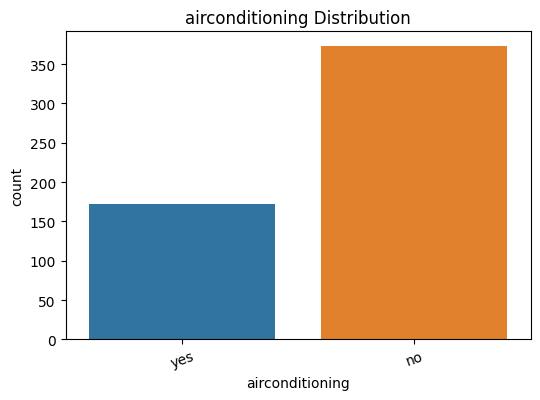

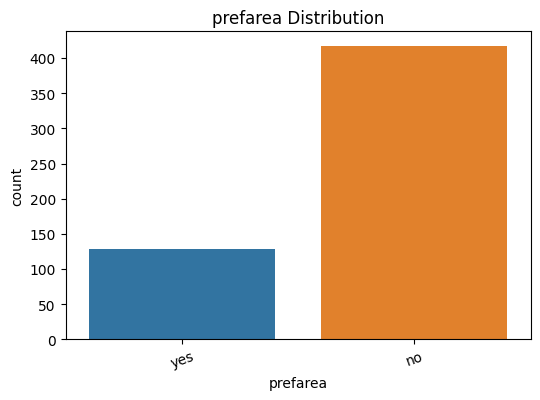

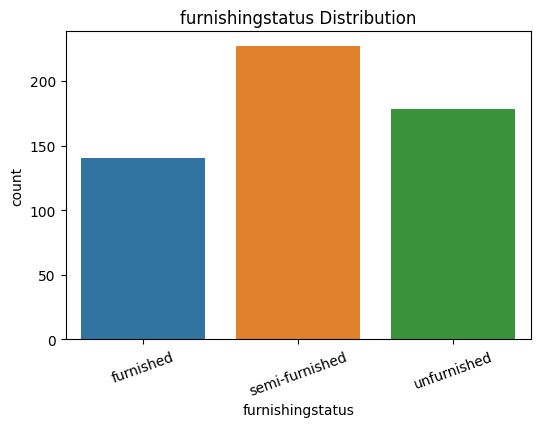

In [40]:
for column in categorical_columns:
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(data=df, x=column)
    
    plt.title(f"{column} Distribution")
    
    plt.xticks(rotation=20)
    
    plt.show()

## 7. Correlation Analysis

In [41]:
eda_df = df.copy()

yes_no_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in yes_no_columns:
    eda_df[col] = eda_df[col].map({
        "yes":1,
        "no":0
    })

eda_df["furnishingstatus"] = eda_df["furnishingstatus"].map({
    "furnished":2,
    "semi-furnished":1,
    "unfurnished":0
})

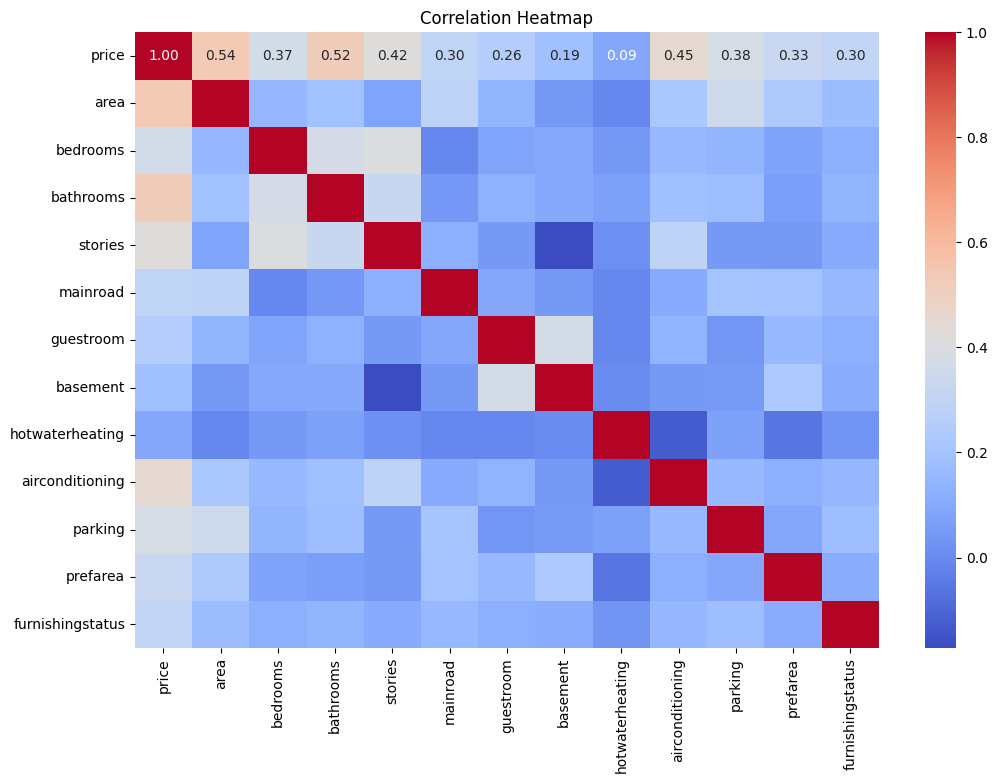

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(
    eda_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Notice which features have the strongest correlation with house price.

Generally, area, bathrooms, airconditioning and stories have a positive relationship with price.

## 8. Relationship with Target Variable

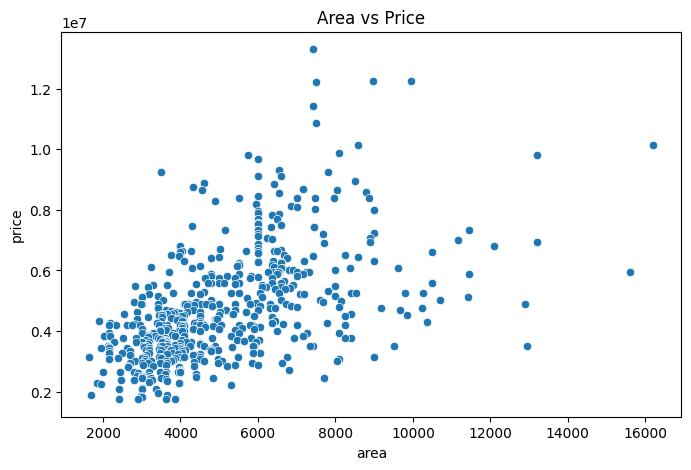

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="area",
    y="price"
)

plt.title("Area vs Price")

plt.show()

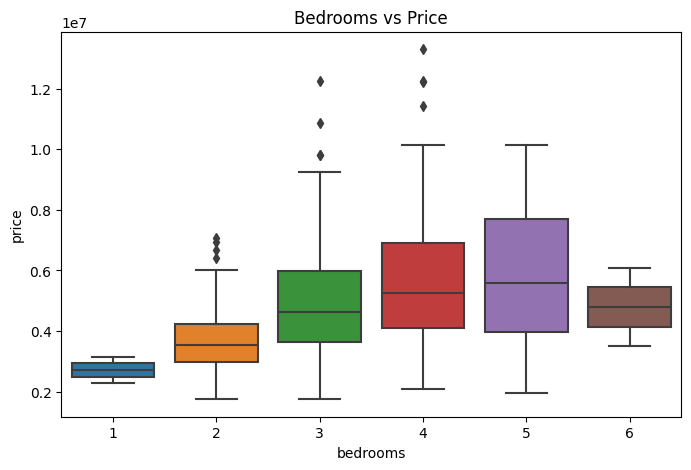

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="bedrooms",
    y="price"
)

plt.title("Bedrooms vs Price")

plt.show()

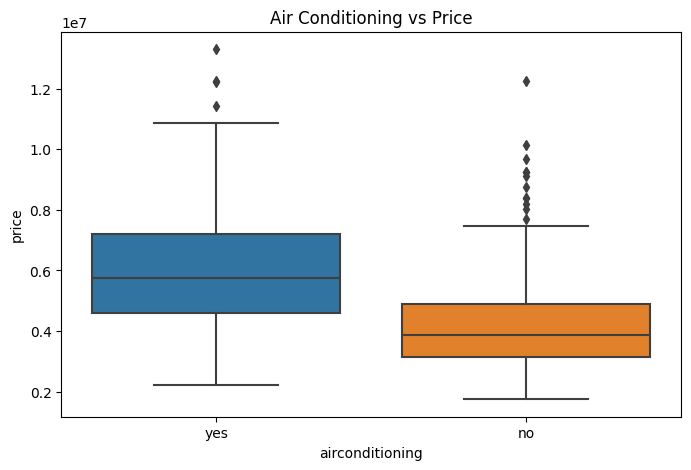

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="airconditioning",
    y="price"
)

plt.title("Air Conditioning vs Price")

plt.show()

## 9. Outlier Detection

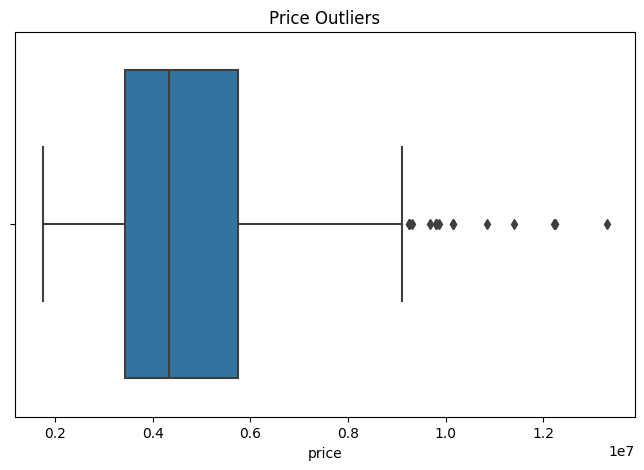

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("Price Outliers")

plt.show()

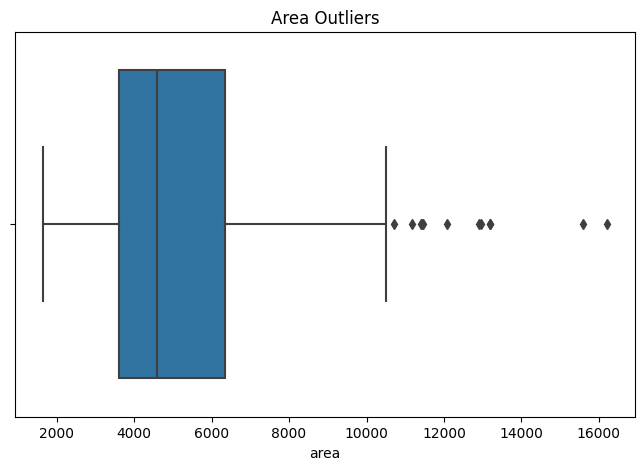

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["area"])

plt.title("Area Outliers")

plt.show()

# EDA Summary

## Key Findings

- Dataset contains no missing values.
- Dataset contains both numerical and categorical features.
- House prices are right-skewed.
- Area has a strong positive relationship with price.
- Air conditioning and furnishing status influence house prices.
- Some numerical features contain outliers.
- Dataset is ready for preprocessing.